<a href="https://colab.research.google.com/github/sherlyazkiah/PCVK/blob/main/Week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Import library

In [3]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

3. Manually create a Global Threshold (BINARY, BINARY_INV, TRUNC, TOZERO,
TOZERO_INV)

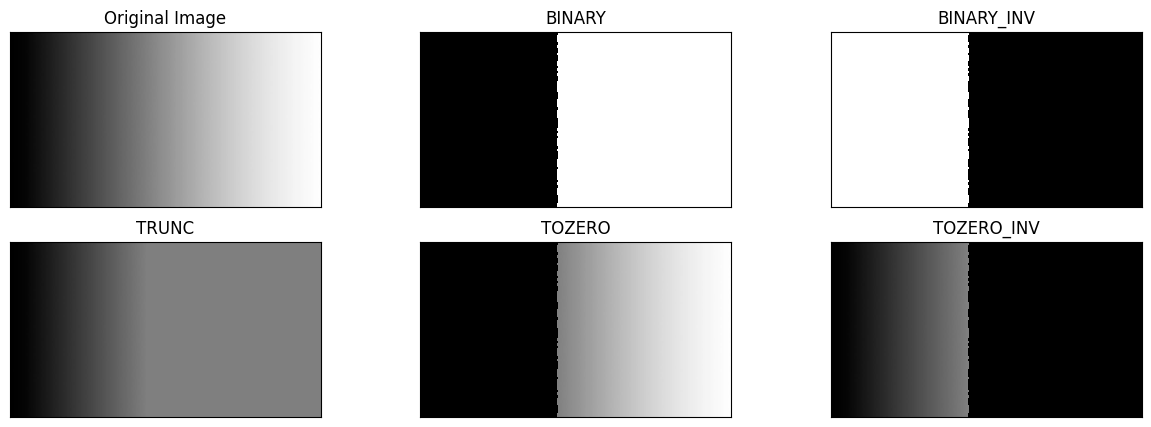

In [4]:
filename = '/content/drive/MyDrive/PCVK/Images/gradient.jpg'
img = cv.imread(filename)
thresh = 127  # nilai threshold yang ditentukan

# 1. thresh1: jika pixel di img > 127, maka thresh1 bernilai 255 (putih), selain itu 0 (hitam)
ret, thresh1 = cv.threshold(img, thresh, 255, cv.THRESH_BINARY)

# 2. thresh2: binary threshold inverse
ret, thresh2 = cv.threshold(img, thresh, 255, cv.THRESH_BINARY_INV)

# 3. Threshold Truncate
ret, thresh3 = cv.threshold(img, thresh, 255, cv.THRESH_TRUNC)

# 4. Threshold ToZero
ret, thresh4 = cv.threshold(img, thresh, 255, cv.THRESH_TOZERO)

# 5. Threshold ToZero Inverse
ret, thresh5 = cv.threshold(img, thresh, 255, cv.THRESH_TOZERO_INV)

titles = ['Original Image', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

plt.figure(figsize=(15, 5))
for i in range(len(images)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], 'gray', interpolation='nearest')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])

plt.show()


4.	Create Otsu Thresholding without using the library. Also display the threshold value when you use Otsu's, as shown in the following image. (use the image lena_gs_lc2.jpg so that it really looks different between the otsu's results and the usual global threshold).

/tmp/ipython-input-3466240242.py:46: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(blur.ravel(), 256, [0, 256])


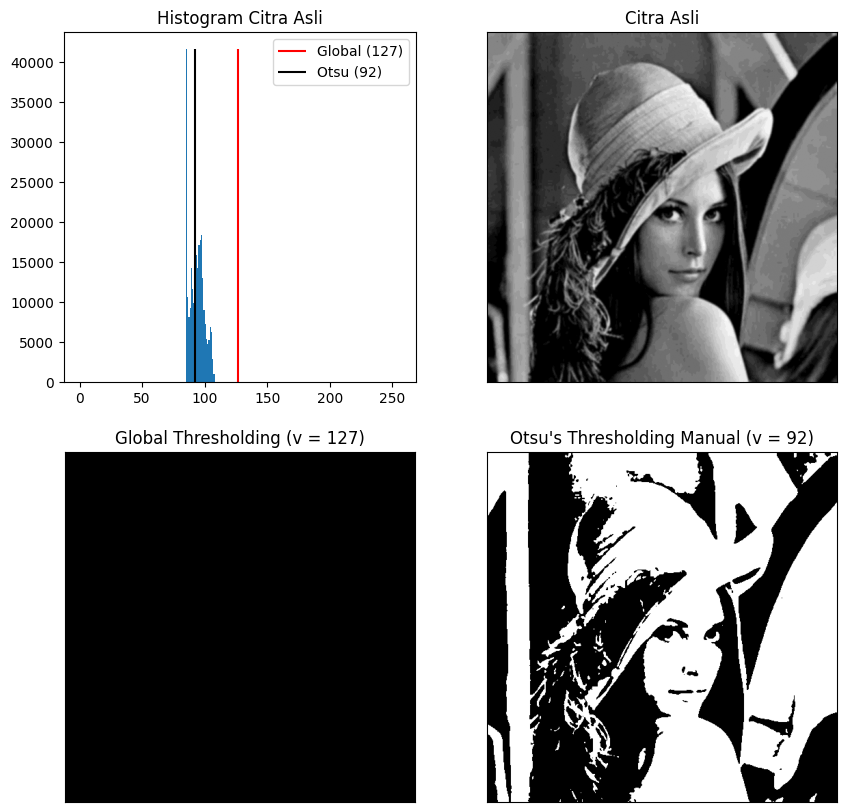

In [7]:
# Load image
filename = '/content/drive/MyDrive/PCVK/Images/lena_gs_lc2.jpg'
img = cv.imread(filename, 0)

# Apply Gaussian Blur to reduce noise
blur = cv.GaussianBlur(img, (5, 5), 0)

# Global Thresholding
thresh = 127
ret, th_global = cv.threshold(blur, thresh, 255, cv.THRESH_BINARY)

# --- Manual Otsu’s Threshold Calculation ---
hist, bins = np.histogram(blur.ravel(), 256, [0, 256])
total = blur.size
current_max, threshold = 0, 0
sum_total = np.dot(np.arange(256), hist)
sumB, wB, wF = 0, 0, 0

for i in range(256):
    wB += hist[i]
    if wB == 0:
        continue
    wF = total - wB
    if wF == 0:
        break
    sumB += i * hist[i]
    mB = sumB / wB
    mF = (sum_total - sumB) / wF
    between_var = wB * wF * (mB - mF) ** 2
    if between_var > current_max:
        current_max = between_var
        threshold = i

# Apply manual Otsu threshold
_, th_otsu_manual = cv.threshold(blur, threshold, 255, cv.THRESH_BINARY)

# Display results
x = f"Otsu's Thresholding Manual (v = {threshold})"
titles = ['Citra Asli', 'Global Thresholding (v = 127)', x]
images = [blur, th_global, th_otsu_manual]

plt.figure(figsize=(10, 10))

# Plot histogram with threshold lines
plt.subplot(2, 2, 1)
plt.hist(blur.ravel(), 256, [0, 256])
plt.vlines(thresh, 0, max(hist), colors='red', label='Global (127)')
plt.vlines(threshold, 0, max(hist), colors='black', label=f'Otsu ({threshold})')
plt.legend()
plt.title('Histogram Citra Asli')

# Show images
for i in range(len(images)):
    plt.subplot(2, 2, i + 2)
    plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])

plt.show()

/tmp/ipython-input-2149453170.py:21: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(blur.ravel(), 256, [50, 200])


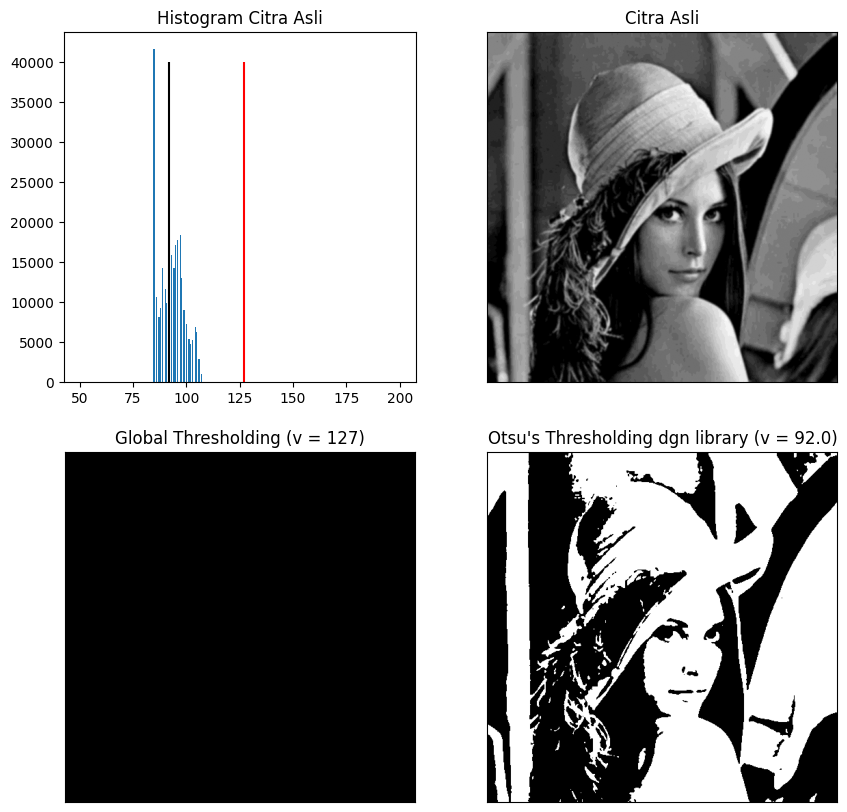

In [5]:
# Dengan Library
filename = '/content/drive/MyDrive/PCVK/Images/lena_gs_lc2.jpg'
img = cv.imread(filename, 0)

# Menghaluskan citra dengan Gaussian Blur
blur = cv.GaussianBlur(img, (5, 5), 0)

# Threshold global dan Otsu's threshold
thresh = 127
ret, th1 = cv.threshold(blur, thresh, 255, cv.THRESH_BINARY)
ret2, th2 = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

x = "Otsu's Thresholding dgn library (v = " + str(ret2) + ")"
titles = ['Citra Asli', 'Global Thresholding (v = 127)', x]
citra3 = [blur, th1, th2]

plt.figure(figsize=(10, 10))

# Histogram citra asli dengan garis threshold
plt.subplot(2, 2, 1)
plt.hist(blur.ravel(), 256, [50, 200])
plt.vlines(ret, 0, 40000, colors='red')   # garis vertikal merah = threshold global 127
plt.vlines(ret2, 0, 40000, colors='black') # garis vertikal hitam = threshold Otsu (hasil)
plt.title('Histogram Citra Asli')

# Menampilkan hasil citra
for i in range(len(citra3)):
    plt.subplot(2, 2, i + 2)
    plt.imshow(citra3[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])

plt.show()


Create a histogram from a segmented image, the histogram is only in the foreground image. Use the Lily or Leaves image provided in the images folder.

Instructions:

a. You can use cv.calcHist to display a histogram.

b. Open the folloiwng link https://opencvtutorial.
readthedocs.io/en/latest/histogram/histogram.html

c. From the link, note that cv.calcHist has one of the parameters, namely mask. If set to None, the entire image histogram will be counted. If we specify a mask, only the part of the image masked in white will be calculated for the histogram (from the example below it is called Image Segment).

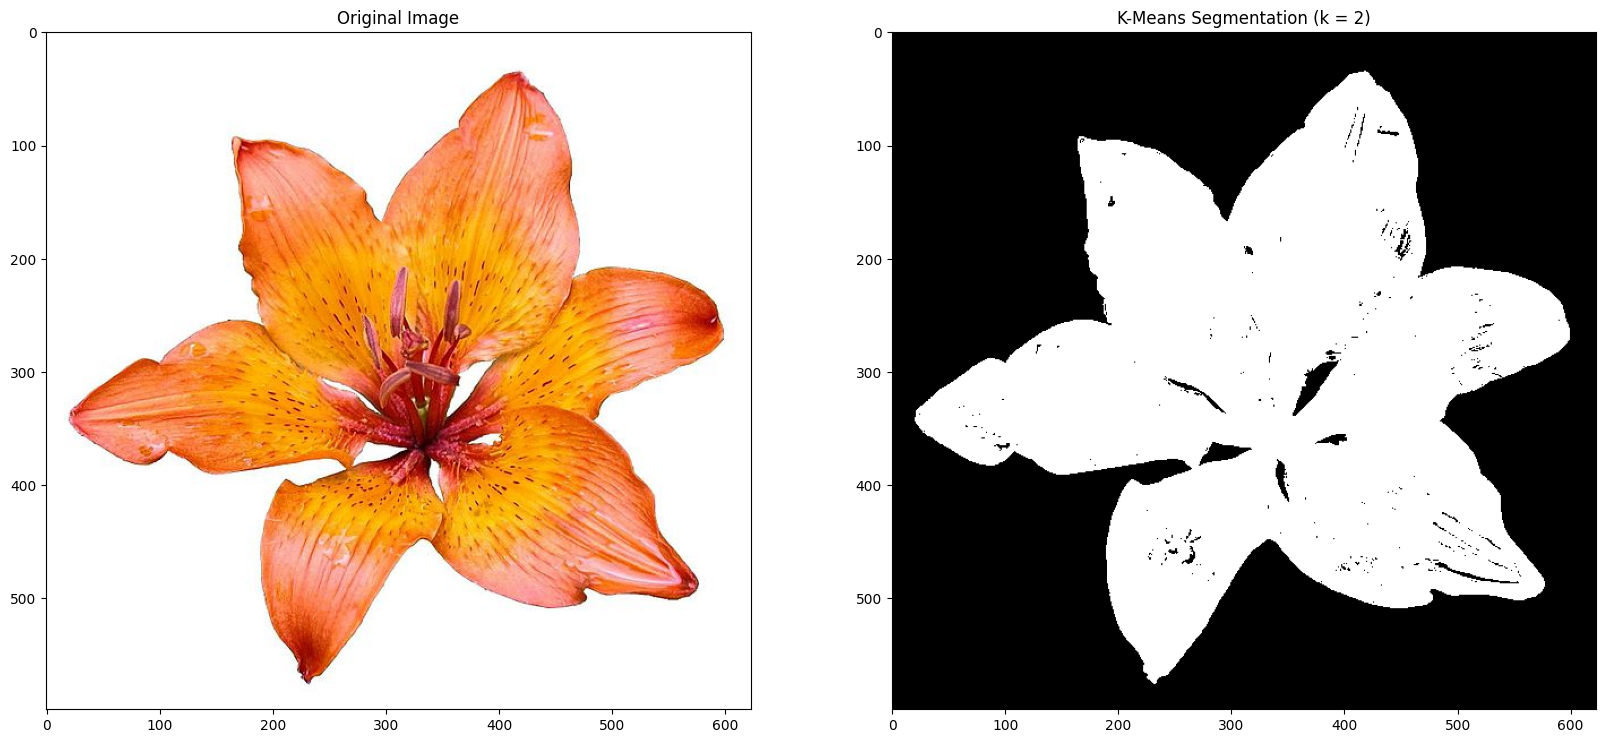

In [24]:
# KMeans image segmentation (grayscale)
filename = '/content/drive/MyDrive/PCVK/Images/lily.jpg'
ori = cv.imread(filename)
img = cv.cvtColor(ori, cv.COLOR_BGR2GRAY)

# Convert image to 2D array
pixel_values = img.reshape((-1, 1))
pixel_values = np.float32(pixel_values)

# Define criteria and number of cluster
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)
k = 2

# KMeans clustering
_, labels, centers = cv.kmeans(
    pixel_values, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS
)

# Convert to integer
centers = np.uint8(centers)

# Flatten array label
labels = labels.flatten()

# Convert each pixels to centroid's intensity
segmented_image = centers[labels]
segmented_image = segmented_image.reshape(img.shape)

segmented_image = cv.bitwise_not(segmented_image)

# Show result
plt.figure(figsize=(20, 20))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(ori, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis()

plt.subplot(1, 2, 2)
plt.imshow(segmented_image, cmap='gray')
plt.title(f'K-Means Segmentation (k = {k})')
plt.axis()

plt.show()